In [ ]:
import pandas as pd
import os
from sklearn.preprocessing import MinMaxScaler
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [ ]:
!pip install tigramite

In [ ]:
import tigramite
import tigramite.data_processing as pp
import tigramite.plotting as tp

from tigramite.models import LinearMediation, Models
from tigramite.causal_effects import CausalEffects

from tigramite.pcmci import PCMCI
from tigramite.independence_tests.robust_parcorr import RobustParCorr

We study a data set from the European Spallation Source (ESS). The data was generated by the ACCP system (a refrigeration system), and system experts have constructed a ground-truth causal graph from their knowledge of the system. All details can be found in this paper

S.W.Mogensen, K.Rathsman, P.Nilsson, Causal discovery in a complex industrial system: A time series benchmark, in Proceedings of the 3rd Conference on Causal Learning and Reasoning (CLeaR), 2024, https://doi.org/10.48550/arXiv.2310.18654

In [ ]:
df_clean=pd.read_csv('/content/data_clean.csv')
df_clean.drop(columns=['Unnamed: 0'],inplace=True)
df_clean.head()

,PT_31220,PT_31483,PT_31221,PT_31490,TT_31452,TT_31401,GT_33011,GT_33010,PT_33009,FT_33012,...,GT_31630,TT_31650,EH_31890,EH_32890,GT_32891,GT_31890,GT_32892,EH_32891,PT_32890,PDT_32890
0,11.767217,1.074581,6.628328,11.757452,19.447096,19.676153,54.311342,0.712529,1.084798,5.490916,...,3.647039,53.057482,1.898871,2.983941,0.936777,0.172405,0.486473,0.632957,0.877942,0.091869
1,11.748861,1.068251,6.633572,11.733128,19.444772,19.676020,54.413519,0.725188,1.084798,5.504649,...,3.630461,53.055884,2.102322,2.848307,0.914171,0.166377,0.471101,0.904224,0.879223,0.091869
2,11.782987,1.070313,6.627388,11.746094,19.441172,19.683080,54.432507,0.731518,1.085250,5.542995,...,3.637876,53.051423,2.079716,2.893518,0.916522,0.159144,0.468750,0.768591,0.880064,0.090965
3,11.765408,1.077691,6.619792,11.729601,19.443956,19.694753,54.325809,0.737847,1.088180,5.596163,...,3.651620,53.048779,2.068414,2.893518,0.928096,0.203993,0.480143,0.881619,0.879449,0.090965
4,11.799480,1.074870,6.624349,11.715929,19.444416,19.678449,54.388743,0.726092,1.085793,5.529259,...,3.656684,53.053286,1.980252,2.848307,0.917245,0.174334,0.478335,0.786675,0.879413,0.090784


In [ ]:
var_names=df_clean.columns
var_names

Index(['PT_31220', 'PT_31483', 'PT_31221', 'PT_31490', 'TT_31452', 'TT_31401',
       'GT_33011', 'GT_33010', 'PT_33009', 'FT_33012',
       ...
       'GT_31630', 'TT_31650', 'EH_31890', 'EH_32890', 'GT_32891', 'GT_31890',
       'GT_32892', 'EH_32891', 'PT_32890', 'PDT_32890'],
      dtype='object', length=143)

In [ ]:
temp = 'TT'
pressure='PT'
speed='ST'
var_TT = list(filter(lambda x: temp in x, var_names))
var_PT=list(filter(lambda x: pressure in x, var_names))
var_ST=list(filter(lambda x: speed in x, var_names))

In [ ]:
dfTT=df_clean[var_TT]
dfPT=df_clean[var_PT]
dfST=df_clean[var_ST]

In [ ]:
dfTT.head()

,TT_31452,TT_31401,TT_349011,TT_34950,TT_349012,TT_348012,TT_348011,TT_34850,TT_34750,TT_347012,...,TT_33701,TT_31330,TT_31355,TT_31530,TT_31555,TT_31550,TT_31730,TT_31755,TT_31640,TT_31650
0,19.447096,19.676153,39.775930,217.155675,40.125866,40.205437,39.906139,156.811361,137.028127,39.301214,...,10.833555,59.261664,39.813090,19.236722,11.519077,14.400475,235.397079,14.989359,39.582663,53.057482
1,19.444772,19.676020,39.773219,217.110748,40.124510,40.207246,39.900715,156.819851,136.982689,39.295788,...,10.831521,59.252017,39.810060,19.235753,11.518707,14.400475,235.411869,14.982327,39.583672,53.055884
2,19.441172,19.683080,39.773218,217.208957,40.124781,40.203177,39.908852,156.729770,136.982339,39.297596,...,10.834072,59.253984,39.811377,19.236453,11.518409,14.400325,235.501926,14.977267,39.580758,53.051423
3,19.443956,19.694753,39.774575,217.209437,40.129121,40.206161,39.899088,156.787671,136.979016,39.296873,...,10.841248,59.259055,39.809583,19.234706,11.517482,14.400614,235.449716,14.978222,39.582597,53.048779
4,19.444416,19.678449,39.775389,217.161356,40.125867,40.201820,39.902342,156.766452,137.006876,39.303022,...,10.850240,59.259873,39.809474,19.233972,11.517418,14.400805,235.393625,14.981188,39.578568,53.053286


In [ ]:
dfPT

,PT_31220,PT_31483,PT_31221,PT_31490,PT_33009,PT_34850,PT_34750,PT_34650,PT_34950,PT_34652,...,PT_31330,PT_31202,PT_31530,PT_31550,PT_31555,PT_31730,PT_31755,PT_31650,PT_31641,PT_32890
0,11.767217,1.074581,6.628328,11.757452,1.084798,1.060872,1.059221,1.060077,1.060692,105.036530,...,11.279298,11.766855,6.489439,2.233435,1.081272,2.202691,2.202329,11.304616,11.720921,0.877942
1,11.748861,1.068251,6.633572,11.733128,1.084798,1.060812,1.059197,1.060095,1.060692,105.036530,...,11.279298,11.741266,6.500380,2.222765,1.081272,2.187771,2.188043,11.304616,11.726346,0.879223
2,11.782987,1.070313,6.627388,11.746094,1.085250,1.060836,1.059269,1.060142,1.060764,105.032913,...,11.255425,11.769966,6.499349,2.241103,1.057943,2.195096,2.207031,11.292680,11.718534,0.880064
3,11.765408,1.077691,6.619792,11.729601,1.088180,1.060872,1.059335,1.060167,1.060764,105.037614,...,11.282118,11.758681,6.502604,2.238932,1.073568,2.196615,2.206163,11.302952,11.731338,0.879449
4,11.799480,1.074870,6.624349,11.715929,1.085793,1.060884,1.059299,1.060041,1.060710,105.039543,...,11.280166,11.751303,6.500217,2.235243,1.061632,2.195909,2.200738,11.280382,11.715278,0.879413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3595,11.837023,1.013455,6.624566,11.837023,1.086408,1.061183,1.059733,1.060475,1.061126,105.038338,...,11.366103,11.847440,6.421658,2.222656,1.074436,2.219184,2.233941,11.351346,11.803386,0.880389
3596,11.859159,1.014323,6.617405,11.815539,1.086552,1.061077,1.059679,1.060431,1.061089,105.034721,...,11.356771,11.820476,6.416016,2.222873,1.064670,2.223669,2.236328,11.361980,11.803115,0.880461
3597,11.856554,1.008681,6.627388,11.808160,1.087927,1.061198,1.059751,1.060456,1.061150,105.034721,...,11.343968,11.840929,6.410808,2.212457,1.056858,2.217665,2.240452,11.376085,11.800348,0.880679
3598,11.862414,1.004774,6.638889,11.789009,1.086733,1.061126,1.059643,1.060475,1.061017,105.039784,...,11.363119,11.842665,6.414714,2.212023,1.063639,2.227865,2.240126,11.348742,11.806858,0.882270


In [ ]:
dfST.head()

,ST_34901,ST_34801,ST_34701,ST_31131,ST_31151,ST_31331,ST_31531,ST_31551,ST_31731
0,0.144676,0.036169,0.192901,2666.811279,2332.175903,2924.672119,2796.706136,1016.022909,2.441406
1,0.189887,0.048225,0.352648,2664.568848,2332.175903,2925.733073,2797.128113,1015.462280,0.843943
2,0.050637,0.156732,0.202546,2665.740723,2330.909912,2925.093994,2796.151563,1015.538232,0.060282
3,0.159144,0.126591,0.126591,2665.422461,2331.336768,2925.897021,2796.043018,1015.885437,1.663773
4,0.065104,0.007234,0.180845,2665.219873,2331.568262,2924.768457,2795.970752,1015.212708,1.853660


## **Presentation of the system**

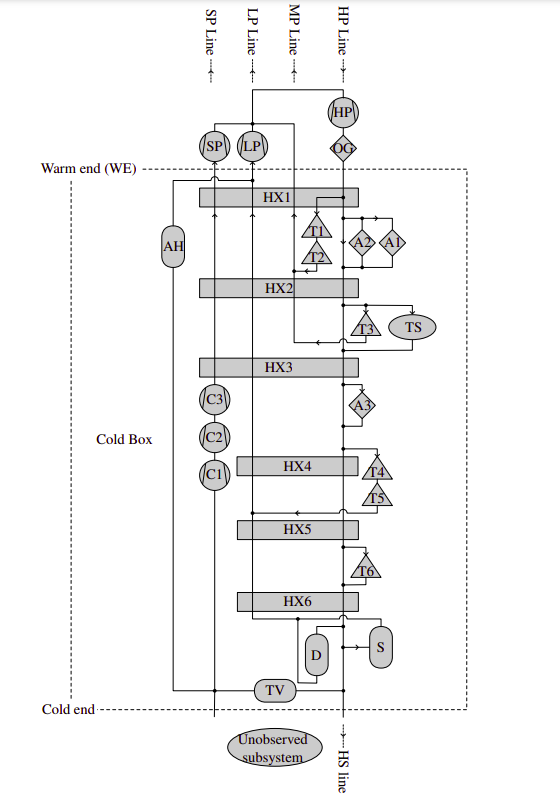

In the diagram below, each node represents a
subsystem and lines indicate a flow of coolant in the direction of the arrow.


The section of the
ACCP between the two dashed lines is the cold box. Starting from the warm end, the ACCP consists of
* three compressors (SP, LP, and HP)
* an oil removal and gas management unit (OG)
* six heat exchangers (HX1, HX2, HX3, HX4, HX5, HX6)
* six turbines (T1,
T2, T3, T4, T5, T6)
* three adsorbers (A1, A2, A3)
* a thermal shield (TS)
* three compressors inside the cold box (C1, C2, C3)
* a helium subcooler (S)
* a dewar (D)
* a test vessel (TV)

From the cold end, the coolant proceeds to a liquid helium bath (HS) where it cools the cavities of the linear
accelerator before returning to the ACCP. No measurements are provided from the liquid helium
bath, and therefore there is an unobserved subsystem below the ACCP in the diagram. The thermal
shield (TS) can also be thought of as partially unobserved as only the pressure, temperature, and
flow of the coolant supplied to/from the thermal shield are observed. No measurements from the TS
itself are available.

There are three additional subsystems (TG, LS, and CG) that are not shown in the functional diagram. They support more than one subsystem.
* The turbine general (TG) supports the six turbines
* LS the low and sub-atmospheric pressure compressors (LP and SP)
* the compressor general (CG) supports the cold compressors (C1, C2 and C3).



A central feature of the ACCP is the circulation of helium. For this reason, it is also natural that
some measurements are made between the subsystems in the diagram in Figure 2.

The interfaces
SPWE, LPWE, MPWE, and HPWE (SP/LP/MP/MP line, warm end) represent measurements made at the warm end dashed line in the diagram, and such measurements are also available in the data.
These interfaces will be referred to as subsystems in the remainder of the paper, despite the fact that
they are links, not actual subsystems

## **Subsystems**

There is a total of 35 subsystems, each of which is a collection of physical components.
* Two of the subsystems are (partially) unobserved (HS and TS), however, the unobserved systems are quite sparsely
connected to the observed systems.
* The HXs are split between the turbine
systems, the SPWE is measured along the edge C3 → SP,
* LPWE is measured between T5 and LP
* MPWE is measured between T2/T3 and LS
* HPWE is measured along the edge from OG to T1
* The dewar (D) is included in the T6 subsystem based on background knowledge and therefore
not shown in the causal graph.
* The TG subsystem interacts with all the turbines (T1, T2, T3, T4,
T5, T6).
However, only a quite weak dependence is expected in stable operations and therefore TG
is also not shown in the causal diagram.

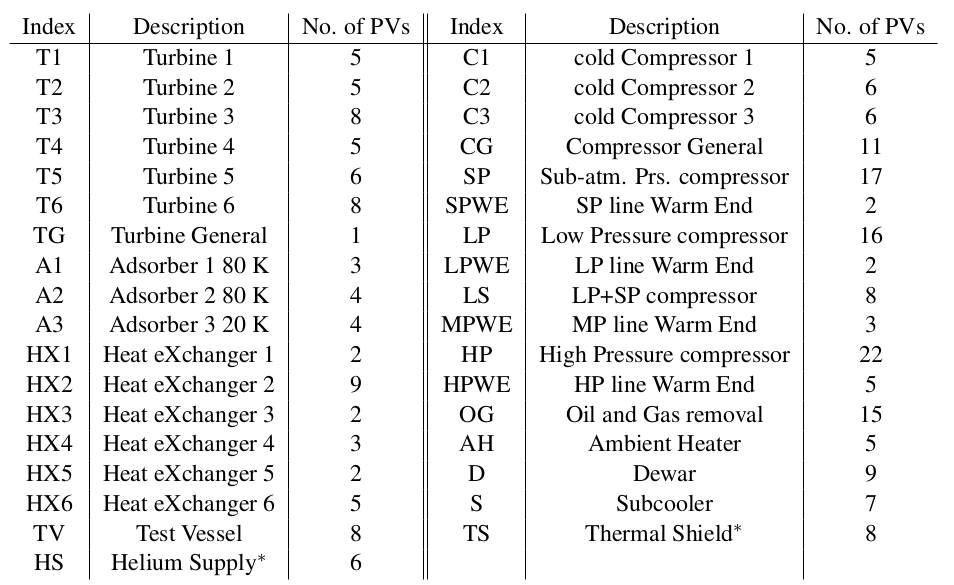

In [ ]:
dir_list=['A1','A2','A3','AH','C1','C2','C3','CG','D','HP','HPWE','HS','HX1','HX2','HX3','HX4','HX5','HX6','LP',
'LPWE','LS','MPWE','OG','S','SP','SPWE','T1','T2','T3','T4','T5','T6','TG','TS','TV']

In [ ]:
dir_list_clean=['A2','A3','AH','C1','C2','C3','CG','D','HPWE','HS','HX2','HX3','HX4','HX5','HX6','OG','S','T1','T2','T3','T4','T5','T6','TS','TV']

## **List of subsystems with corresponding variables**

In [ ]:
lsummary=[['A1', ['PT_31220']],
 ['A2', ['PT_31483', 'PT_31221']],
 ['A3', ['PT_31490', 'TT_31452', 'TT_31401']],
 ['AH', ['GT_33011', 'GT_33010', 'PT_33009', 'FT_33012']],
 ['C1', ['ST_34901', 'FT_38823', 'TT_349011', 'TT_34950', 'TT_349012']],
 ['C2',['TT_348012', 'ST_34801', 'PT_34850', 'TT_348011', 'FT_38822', 'TT_34850']],
 ['C3',['ST_34701', 'TT_34750', 'FT_38821', 'TT_347012', 'PT_34750', 'TT_347011']],
 ['CG',['GT_34998','PT_34650','PDT_34905','PDT_34650','GT_34997','GT_34699','PT_34950','TT_34891','TT_34892','TT_34650','PT_34652']],
 ['D',['GT_31850','GT_33850','GT_33851','PT_31850','TT_33850','LT_63001','PDT_63000','PT_33850','TT_33851']],
 ['HP', []],
 ['HPWE', ['PT_31000', 'PDT_31003', 'FT_31000']],
 ['HS', ['FT_31702', 'TT_31702', 'TT_31801', 'PT_31801', 'GT_31800']],
 ['HX1', []],
 ['HX2',['GT_31201','GT_31202','TT_34203','TT_31203','TT_31202','TT_33203','TT_31302']],
 ['HX3', ['TT_33302', 'TT_34302']],
 ['HX4', ['TT_31402', 'TT_33401', 'TT_33402']],
 ['HX5', ['TT_33501', 'TT_33502']],
 ['HX6', ['TT_33601', 'PT_31602', 'TT_31602', 'TT_33602', 'TT_31601']],
 ['LP', ['PT_23099']],
 ['LPWE', ['PT_33101']],
 ['LS', []],
 ['MPWE', ['PT_32101']],
 ['OG',['FT_21630','FT_21631','GT_21600A','FT_22630','GT_22600A','GT_22600B','GT_21600B','FT_22620','GT_23600A','PT_22600','PT_22631','GT_23600B','PT_21632','PT_22601']],
 ['S',['GT_33798','GT_31709','PDT_31702','PT_33710','GT_31799','TT_33701','PDT_33710']],
 ['SP', ['PT_24099']],
 ['SPWE', ['PT_34101']],
 ['T1', ['ST_31131', 'GT_31130', 'PT_31130']],
 ['T2', ['PT_31150', 'ST_31151']],
 ['T3',['PT_31355','ST_31331','PT_31330','PT_31202','GT_31330','TT_31330','TT_31355']],
 ['T4', ['ST_31531', 'GT_31530', 'TT_31530', 'PT_31530']],
 ['T5', ['TT_31555', 'TT_31550', 'PT_31550', 'ST_31551', 'PT_31555']],
 ['T6',['GT_31730','PT_31730','ST_31731','TT_31730','PT_31755','TT_31755','GT_31750']],
 ['TG', []],
 ['TS',['PT_31650','GT_31650','GT_31620','PT_31641','TT_31640','GT_31630','TT_31650']],
 ['TV',['EH_31890','EH_32890','GT_32891','GT_31890','GT_32892','EH_32891','PT_32890','PDT_32890']]]

In [ ]:
lsummary_clean=[
 ['A2', ['PT_31483', 'PT_31221']],
 ['A3', ['PT_31490', 'TT_31452', 'TT_31401']],
 ['AH', ['GT_33011', 'GT_33010', 'PT_33009', 'FT_33012']],
 ['C1', ['ST_34901', 'FT_38823', 'TT_349011', 'TT_34950', 'TT_349012']],
 ['C2',['TT_348012', 'ST_34801', 'PT_34850', 'TT_348011', 'FT_38822', 'TT_34850']],
 ['C3',['ST_34701', 'TT_34750', 'FT_38821', 'TT_347012', 'PT_34750', 'TT_347011']],
 ['CG',['GT_34998','PT_34650','PDT_34905','PDT_34650','GT_34997','GT_34699','PT_34950','TT_34891','TT_34892','TT_34650','PT_34652']],
 ['D',['GT_31850','GT_33850','GT_33851','PT_31850','TT_33850','LT_63001','PDT_63000','PT_33850','TT_33851']],
 ['HPWE', ['PT_31000', 'PDT_31003', 'FT_31000']],
 ['HS', ['FT_31702', 'TT_31702', 'TT_31801', 'PT_31801', 'GT_31800']],
 ['HX2',['GT_31201','GT_31202','TT_34203','TT_31203','TT_31202','TT_33203','TT_31302']],
 ['HX3', ['TT_33302', 'TT_34302']],
 ['HX4', ['TT_31402', 'TT_33401', 'TT_33402']],
 ['HX5', ['TT_33501', 'TT_33502']],
 ['HX6', ['TT_33601', 'PT_31602', 'TT_31602', 'TT_33602', 'TT_31601']],
 ['OG',['FT_21630','FT_21631','GT_21600A','FT_22630','GT_22600A','GT_22600B','GT_21600B','FT_22620','GT_23600A','PT_22600','PT_22631','GT_23600B','PT_21632','PT_22601']],
 ['S',['GT_33798','GT_31709','PDT_31702','PT_33710','GT_31799','TT_33701','PDT_33710']],
 ['T1', ['ST_31131', 'GT_31130', 'PT_31130']],
 ['T2', ['PT_31150', 'ST_31151']],
 ['T3',['PT_31355','ST_31331','PT_31330','PT_31202','GT_31330','TT_31330','TT_31355']],
 ['T4', ['ST_31531', 'GT_31530', 'TT_31530', 'PT_31530']],
 ['T5', ['TT_31555', 'TT_31550', 'PT_31550', 'ST_31551', 'PT_31555']],
 ['T6',['GT_31730','PT_31730','ST_31731','TT_31730','PT_31755','TT_31755','GT_31750']],
 ['TS',['PT_31650','GT_31650','GT_31620','PT_31641','TT_31640','GT_31630','TT_31650']],
 ['TV',['EH_31890','EH_32890','GT_32891','GT_31890','GT_32892','EH_32891','PT_32890','PDT_32890']]]

## **Example of subsystem : Turbine 2**

* PT_31150,Inlet Temperature,bar,T2,Turbine 2,PT,Pressure Transmitter
* ST_31151,Speed (revolutions per seconds),rps,T2,Turbine 2,ST,Speed Transmitter
* TT_31150,Inlet Temperature,K,T2,Turbine 2,TT,Temperature Transmitter
* TT_31151,Break circuit temperature,degC,T2,Turbine 2,TT,Temperature Transmitter
* TT_31155,Outlet Temperature,K,T2,Turbine 2,TT,Temperature Transmitter


The dataset and the remainder of this paper use the
subsystems represented in the following causal graph

The true graph : note that it is a cluster graph with retroaction

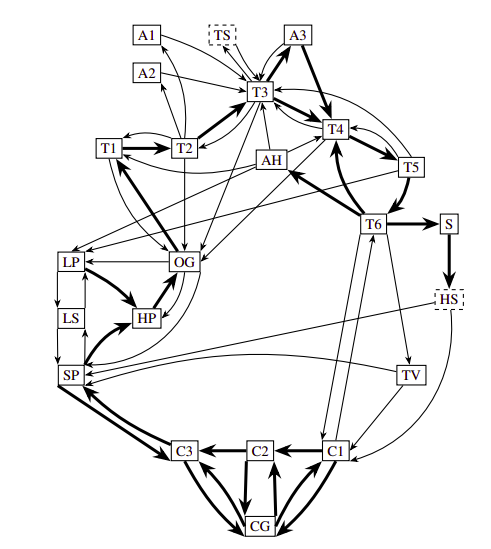

## **Basic plots**

In [ ]:
scaler = MinMaxScaler()
df_normalized = pd.DataFrame(scaler.fit_transform(df_clean), columns=df_clean.columns)

0
A2


<ipython-input-34-bed9ece988ab>:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


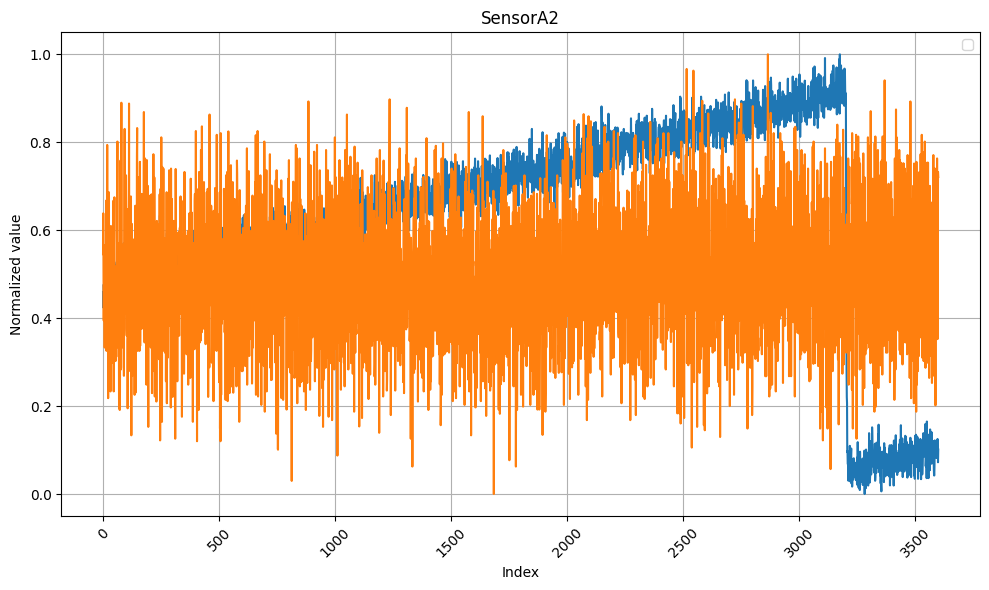

1
A3


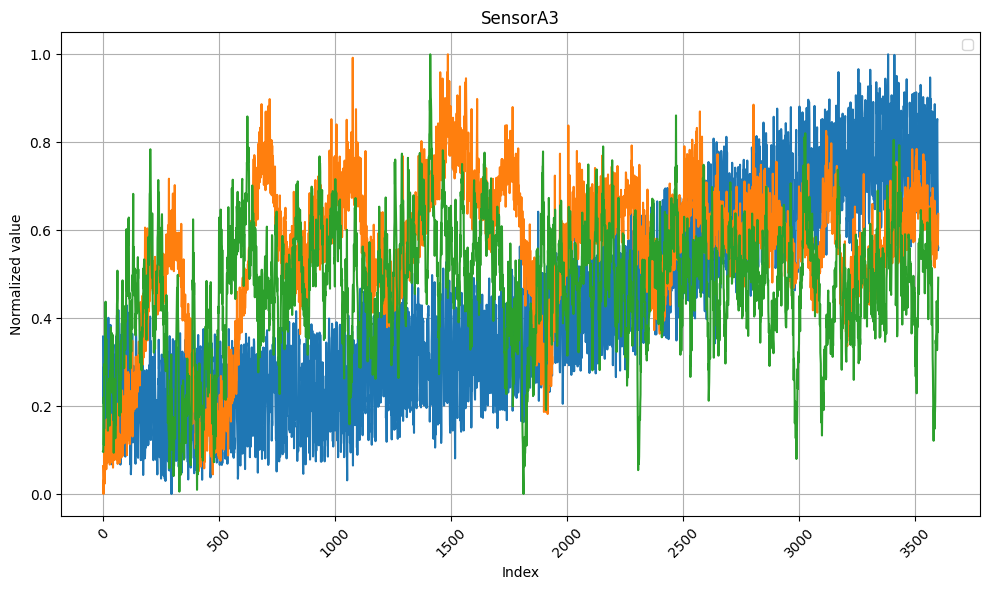

2
AH


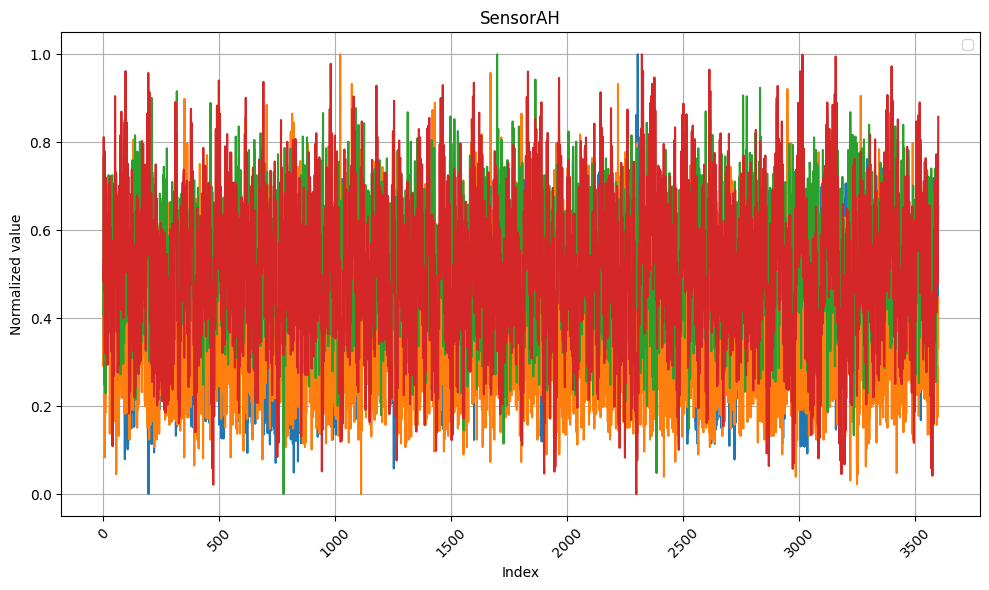

3
C1


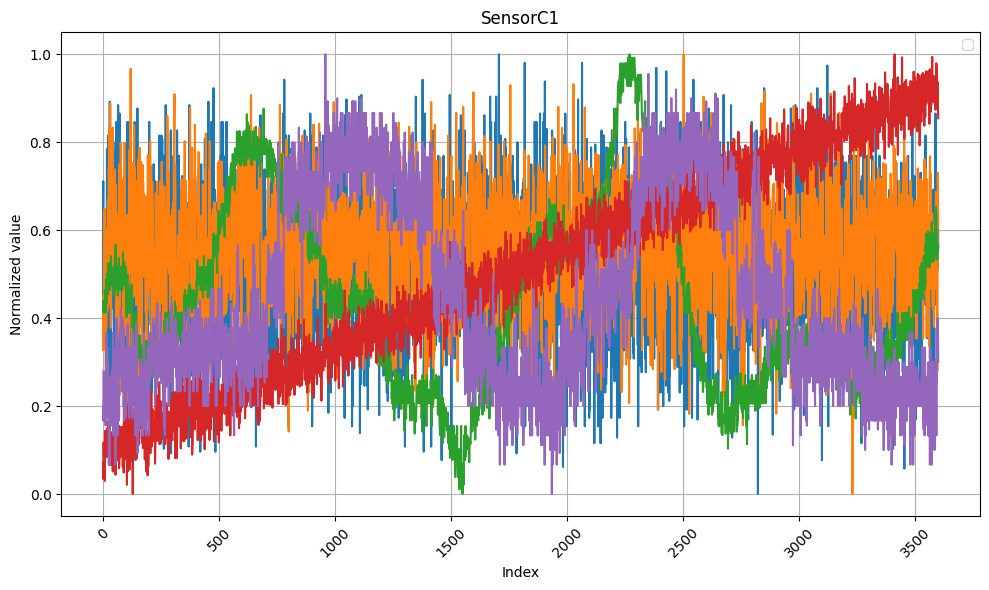

4
C2


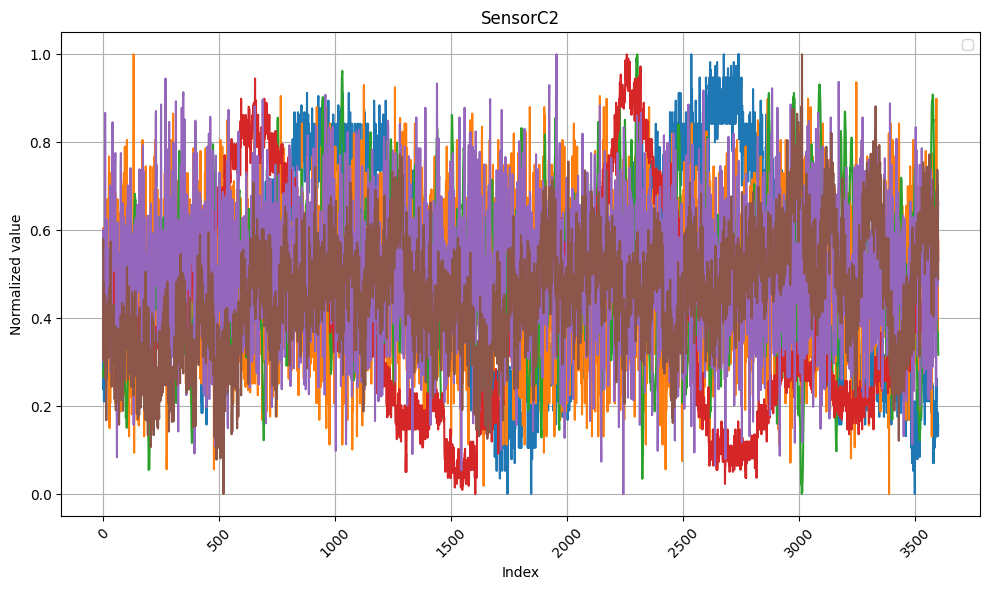

5
C3


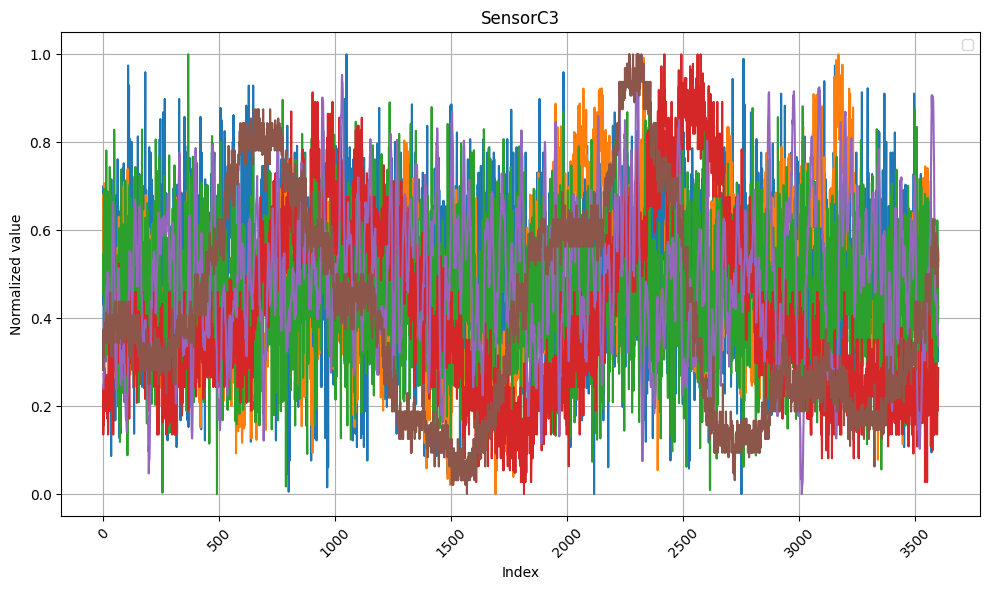

6
CG


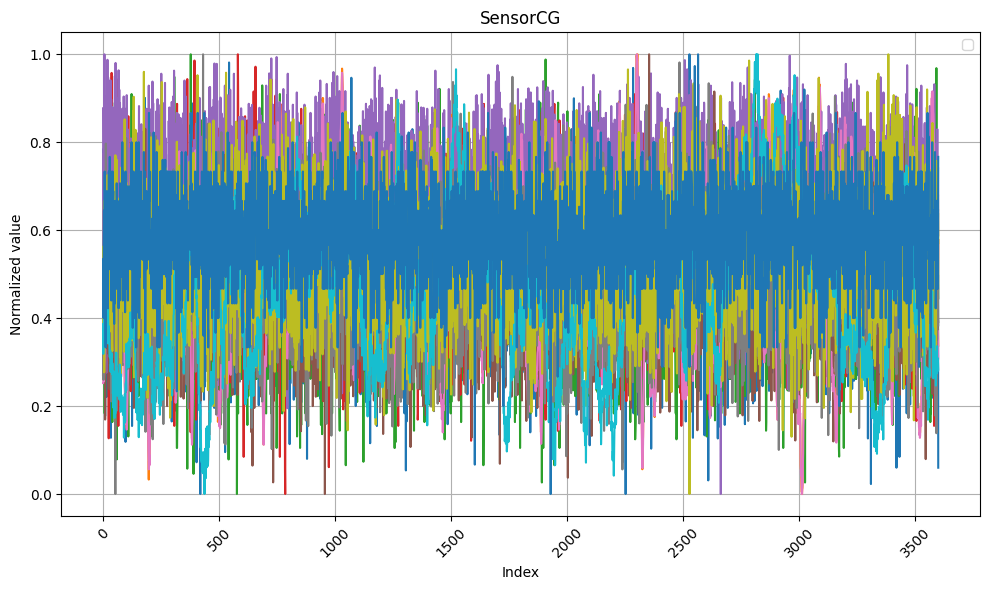

7
D


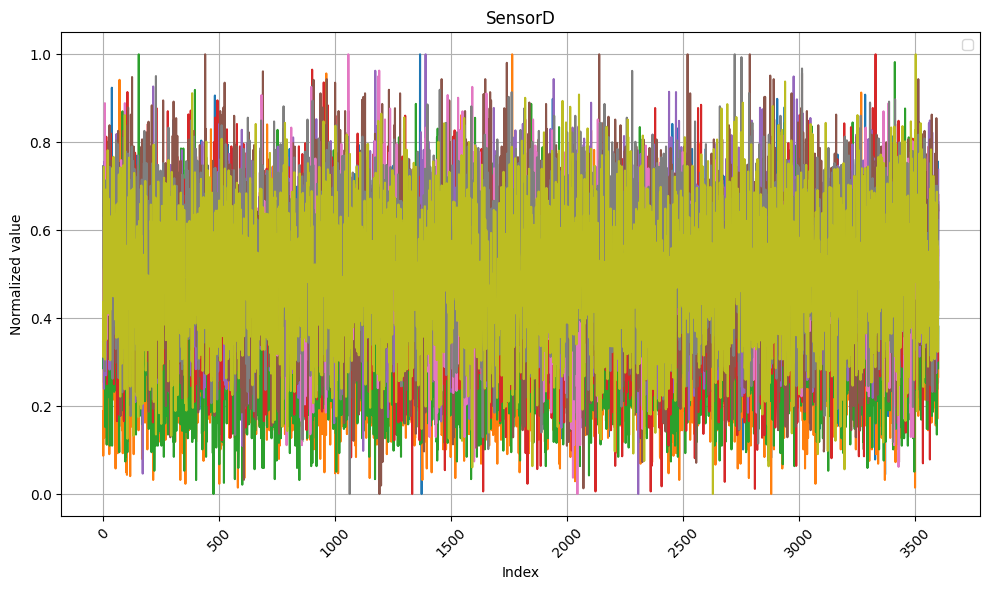

8
HPWE


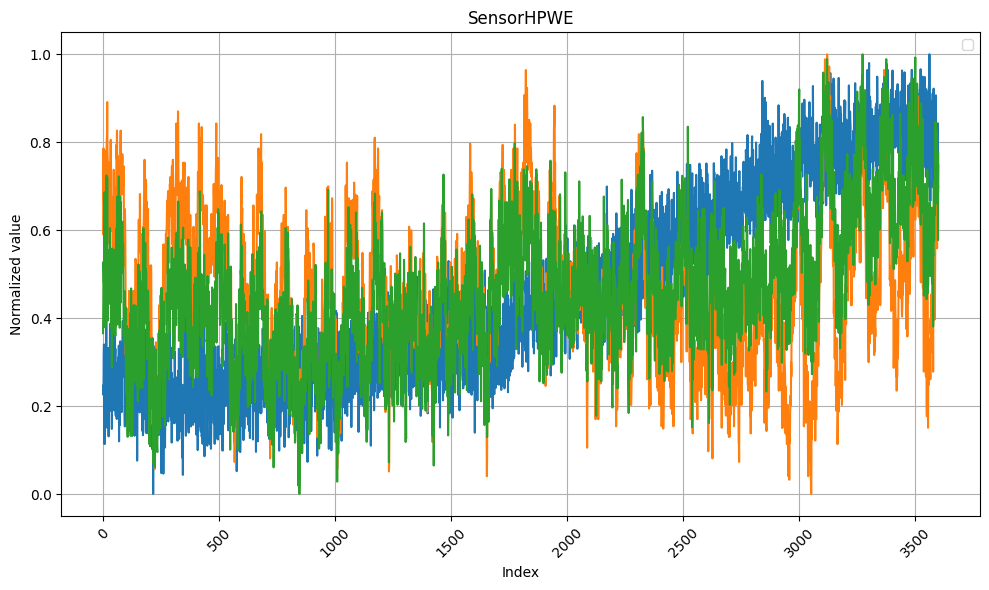

9
HS


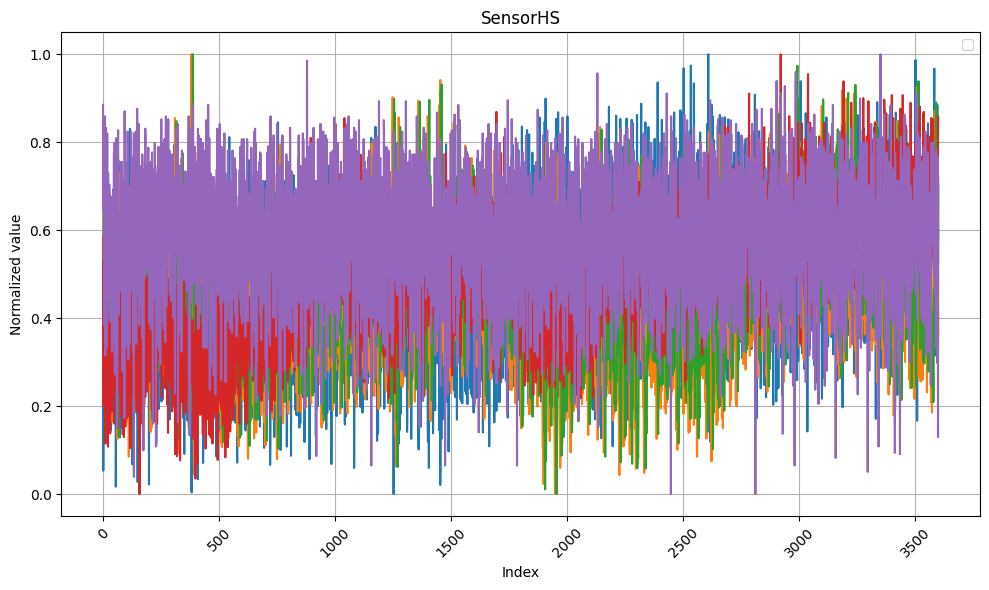

10
HX2


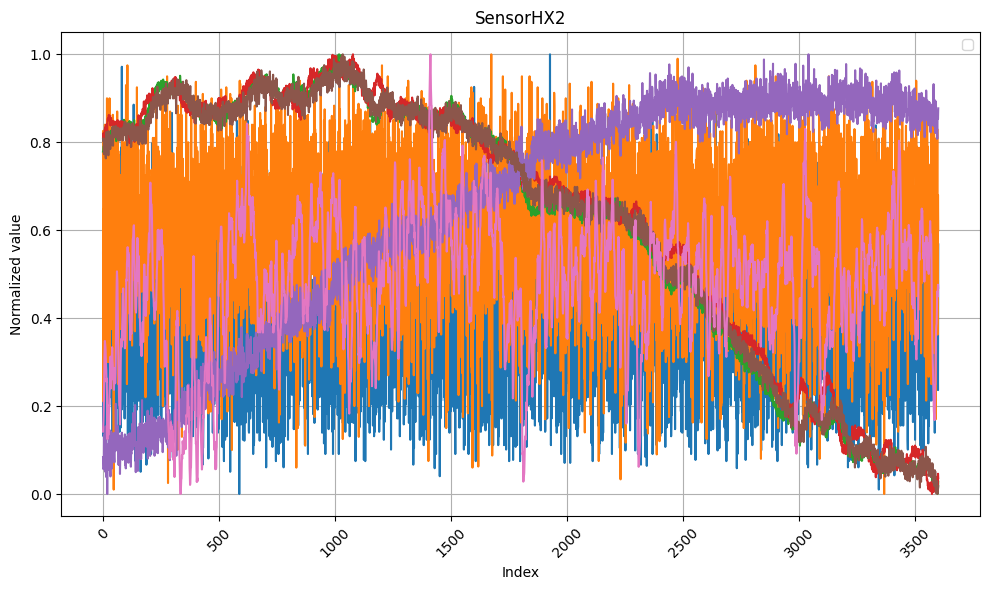

11
HX3


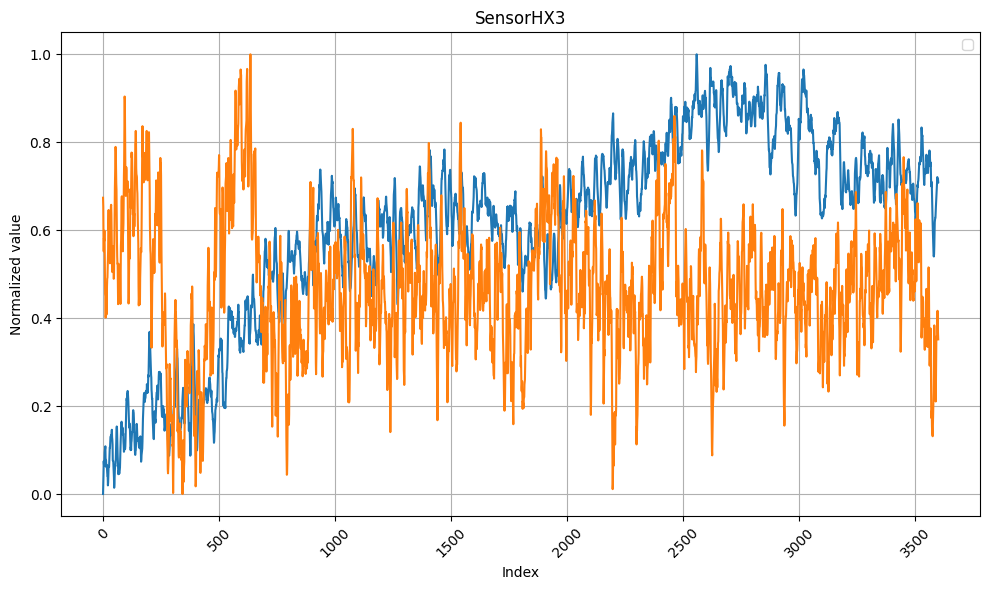

12
HX4


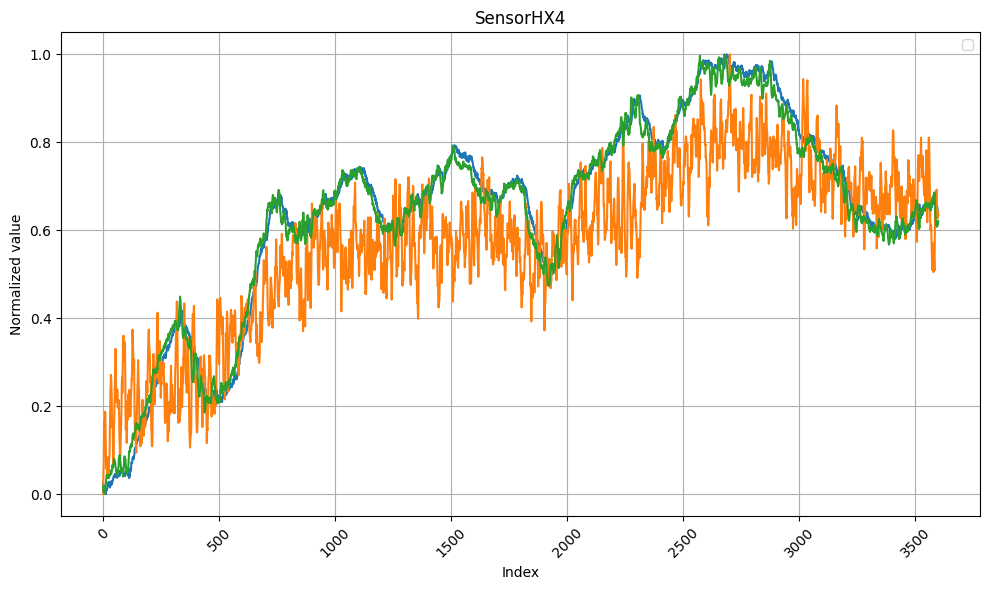

13
HX5


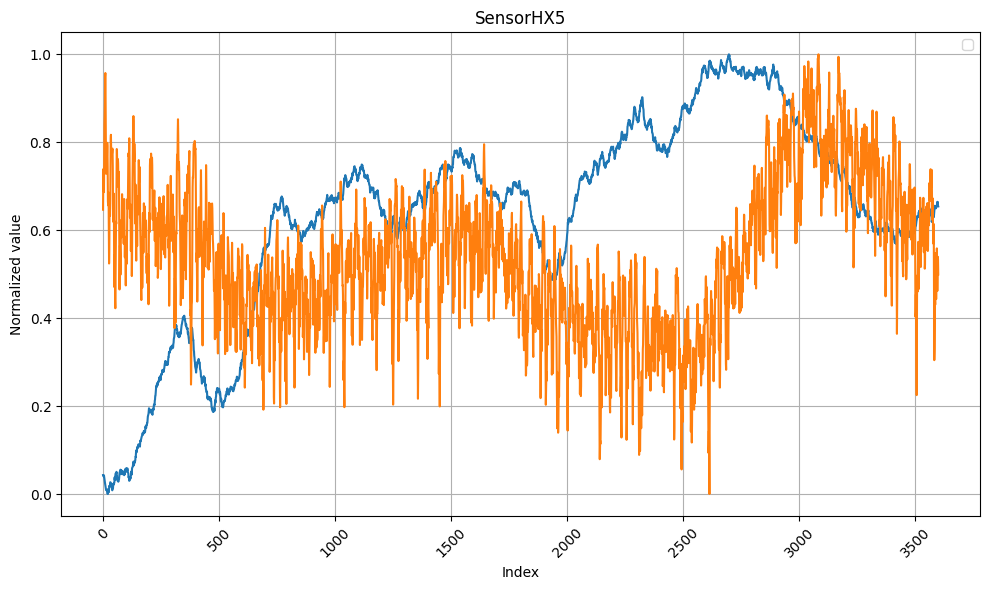

14
HX6


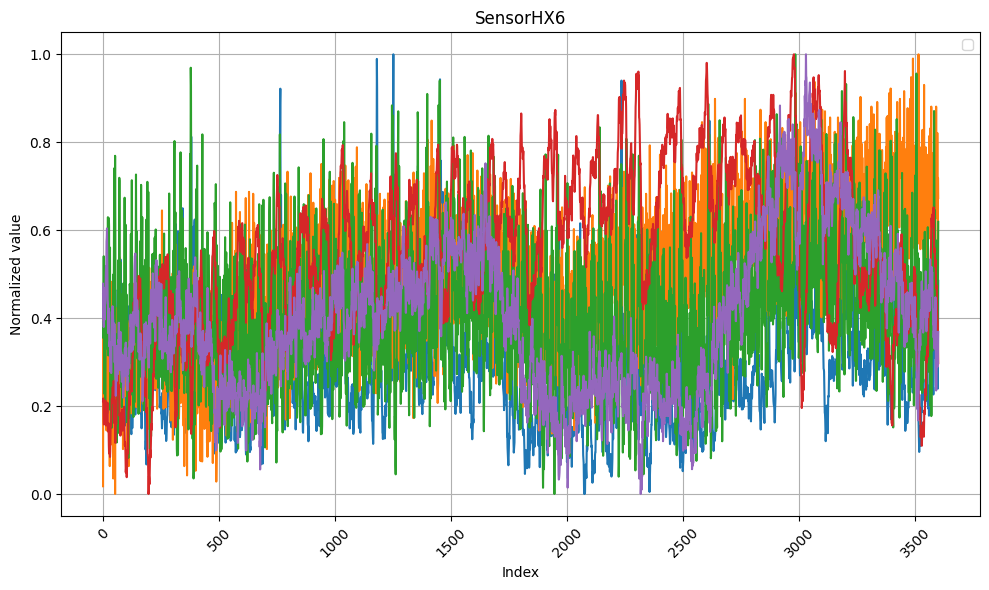

15
OG


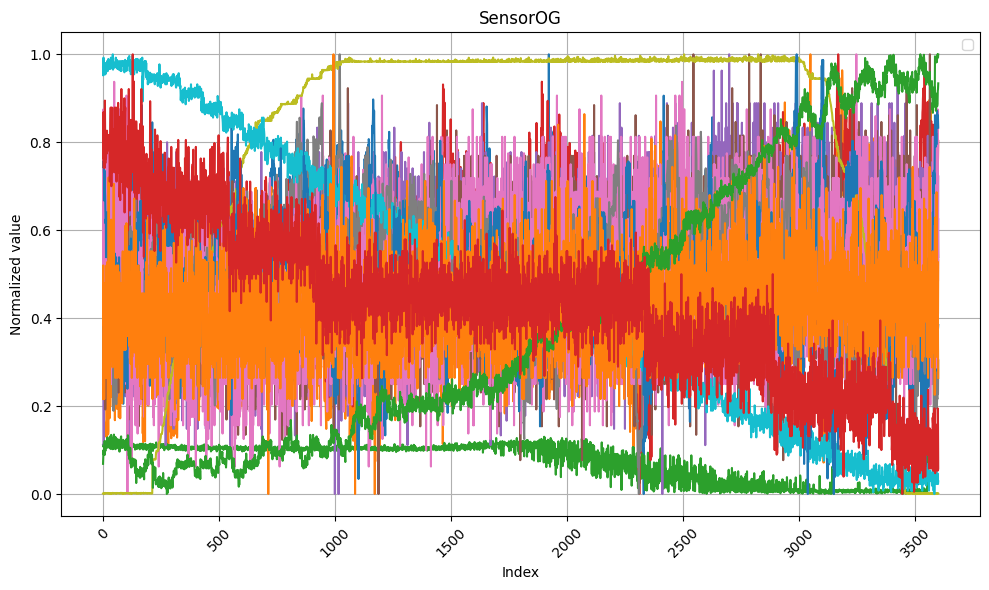

16
S


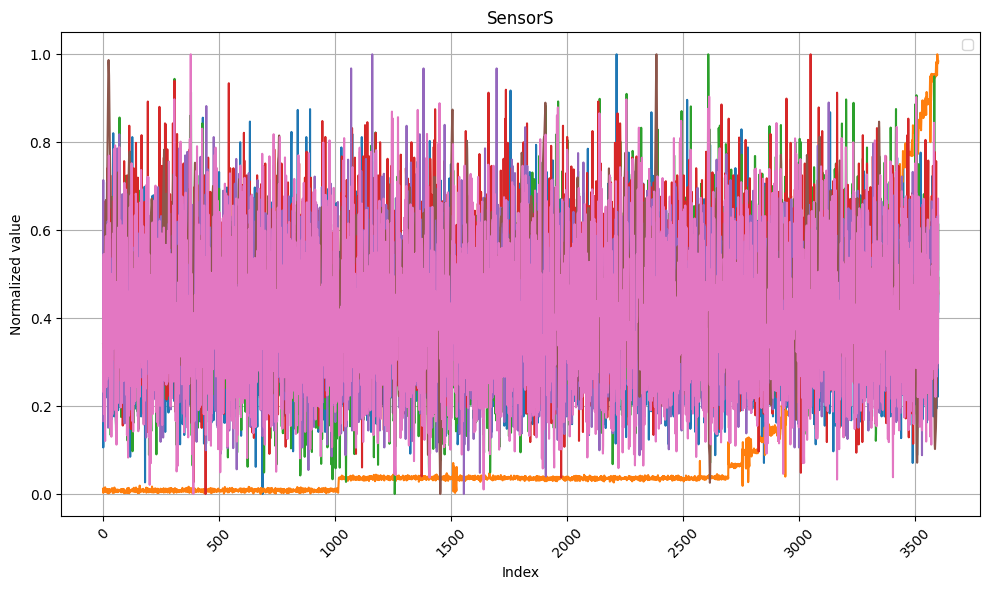

17
T1


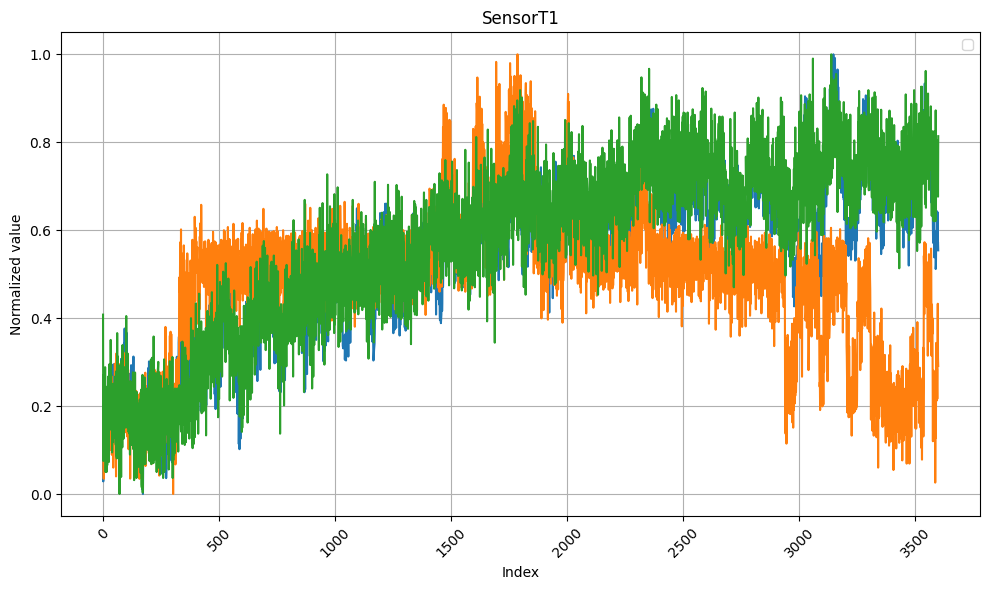

18
T2


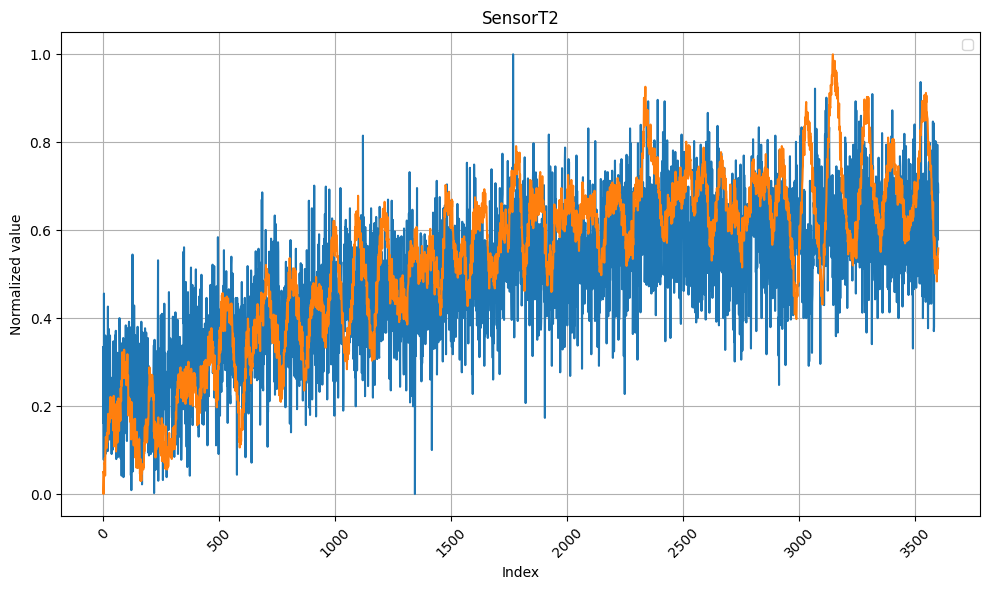

19
T3


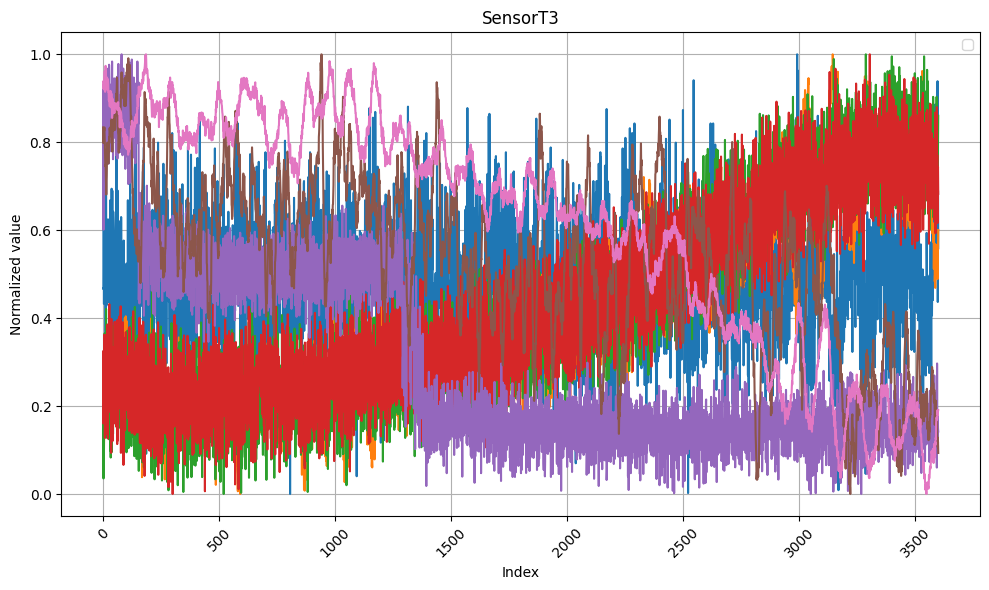

20
T4


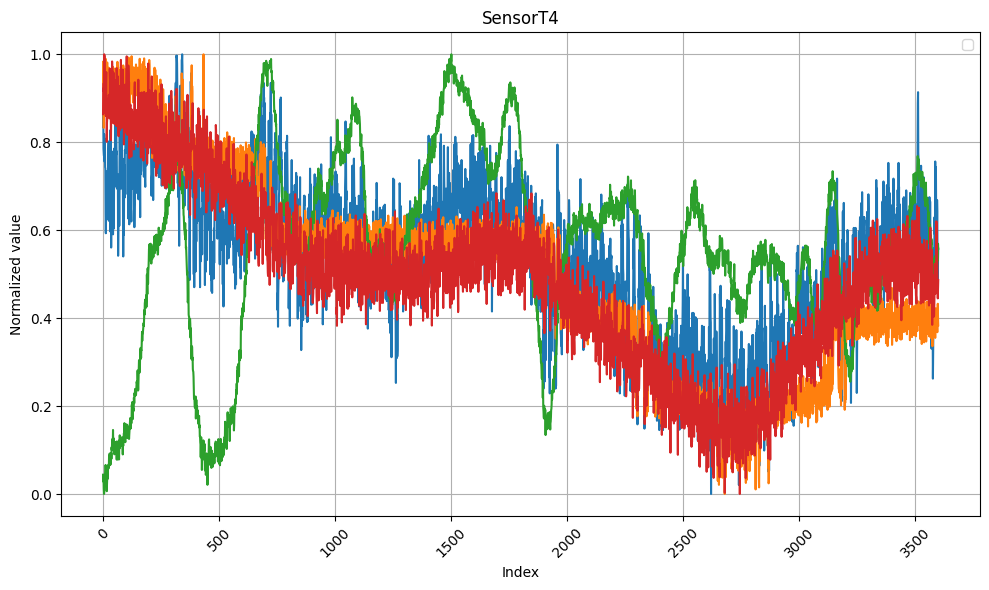

21
T5


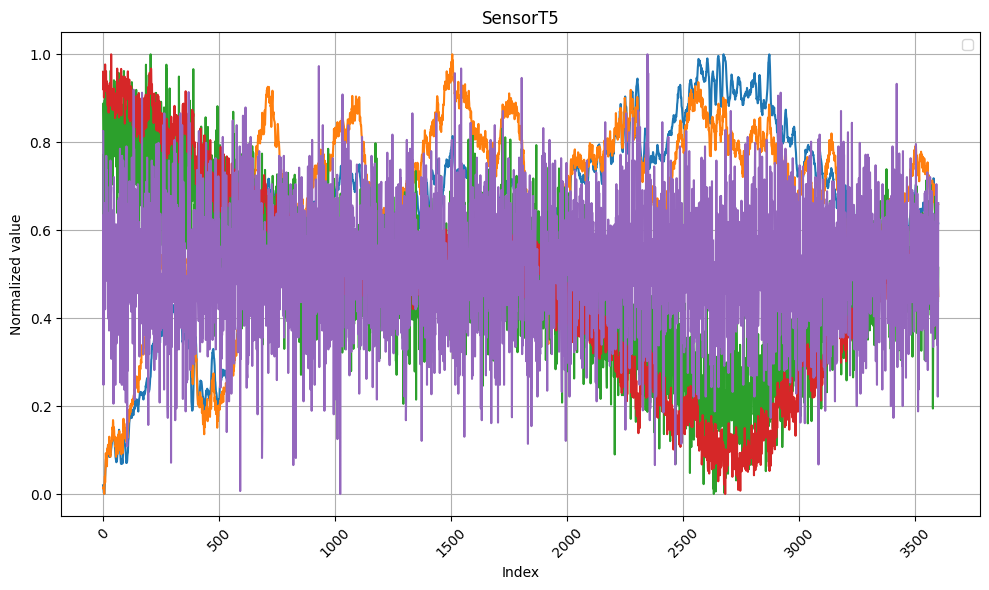

22
T6


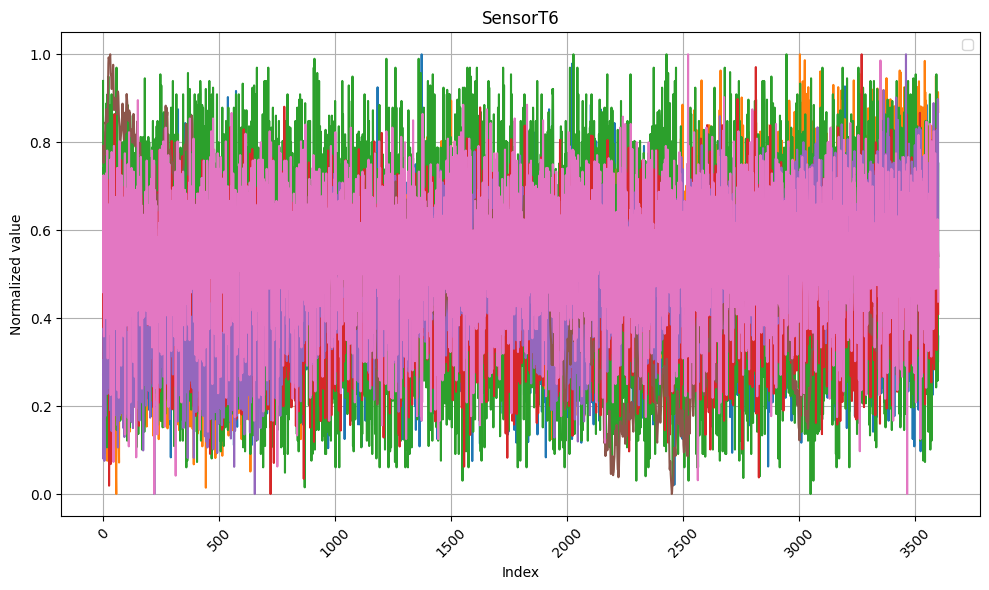

23
TS


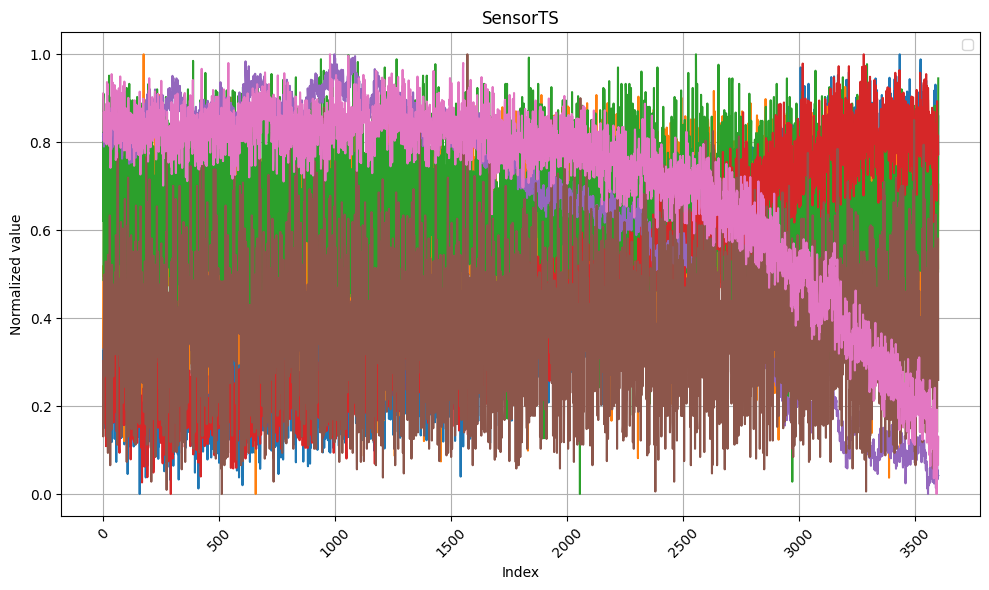

24
TV


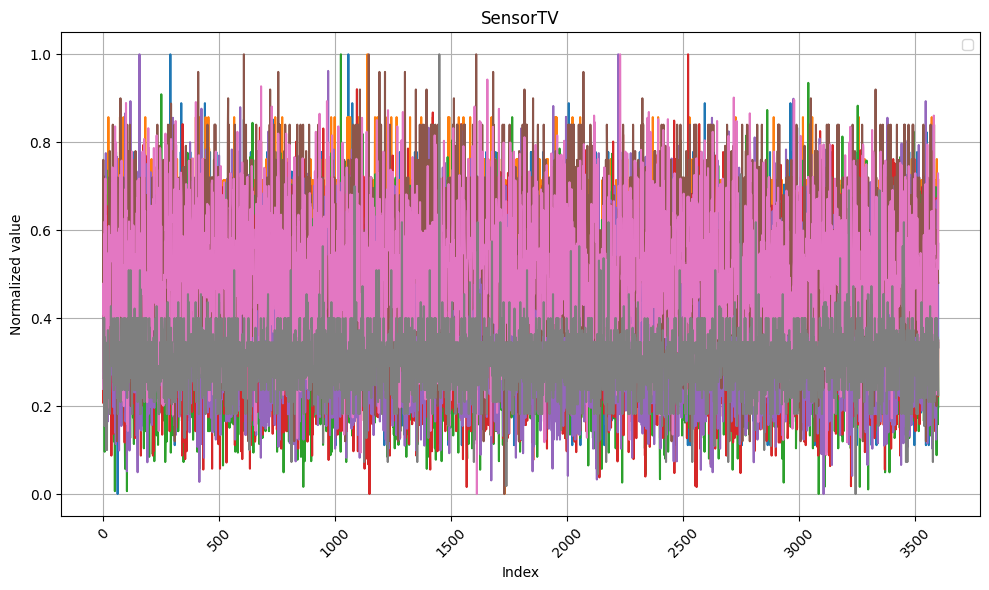

In [ ]:
for index_group in range(len(dir_list_clean)):
    plt.figure(figsize=(10, 6))
    print(index_group)
    print(dir_list_clean[index_group])
    for col in lsummary_clean[index_group][1]:
      plt.plot(df_normalized.index, df_normalized[col])
    plt.xlabel('Index')
    plt.ylabel('Normalized value')
    plt.title('Sensor'+dir_list_clean[index_group])
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    # Show plot
    plt.tight_layout()
    plt.show()

## **Correlation matrix**

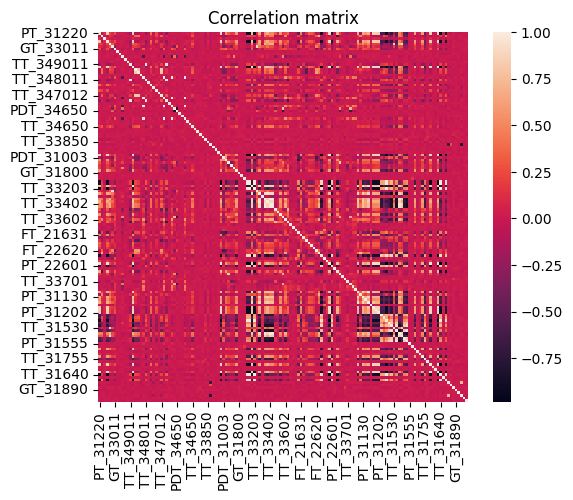

In [ ]:
overall_pearson_r = df_clean.corr()
sns.heatmap(overall_pearson_r, vmax=1., square=True)
plt.title('Correlation matrix')
plt.show()

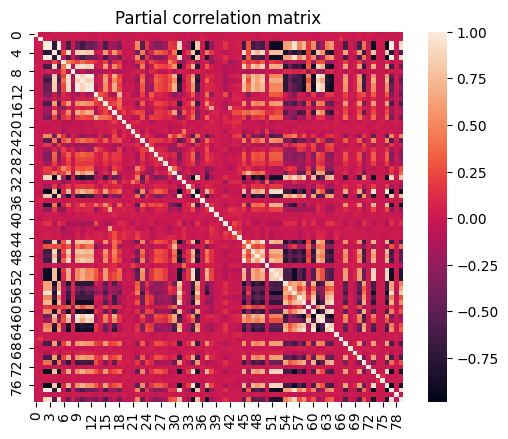

In [ ]:
overall_pearson_r = df_clean.corr()
sns.heatmap(overall_pearson_r.values[55:135,55:135], vmax=1., square=True)
plt.title('Partial correlation matrix')
plt.show()

In [ ]:
df_clean.columns[55:135]

Index(['GT_31201', 'GT_31202', 'TT_34203', 'TT_31203', 'TT_31202', 'TT_33203',
       'TT_31302', 'TT_33302', 'TT_34302', 'TT_31402', 'TT_33401', 'TT_33402',
       'TT_33501', 'TT_33502', 'TT_33601', 'PT_31602', 'TT_31602', 'TT_33602',
       'TT_31601', 'PT_23099', 'PT_33101', 'PT_32101', 'FT_21630', 'FT_21631',
       'GT_21600A', 'FT_22630', 'GT_22600A', 'GT_22600B', 'GT_21600B',
       'FT_22620', 'GT_23600A', 'PT_22600', 'PT_22631', 'GT_23600B',
       'PT_21632', 'PT_22601', 'GT_33798', 'GT_31709', 'PDT_31702', 'PT_33710',
       'GT_31799', 'TT_33701', 'PDT_33710', 'PT_24099', 'PT_34101', 'ST_31131',
       'GT_31130', 'PT_31130', 'PT_31150', 'ST_31151', 'PT_31355', 'ST_31331',
       'PT_31330', 'PT_31202', 'GT_31330', 'TT_31330', 'TT_31355', 'ST_31531',
       'GT_31530', 'TT_31530', 'PT_31530', 'TT_31555', 'TT_31550', 'PT_31550',
       'ST_31551', 'PT_31555', 'GT_31730', 'PT_31730', 'ST_31731', 'TT_31730',
       'PT_31755', 'TT_31755', 'GT_31750', 'PT_31650', 'GT_31650', '

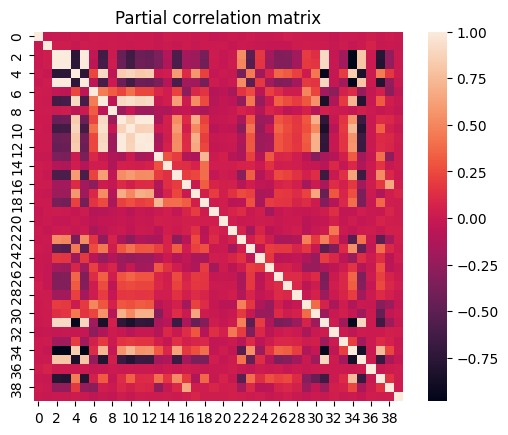

In [ ]:
overall_pearson_r = df_clean.corr()
sns.heatmap(overall_pearson_r.values[55:95,55:95], vmax=1., square=True)
plt.title('Partial correlation matrix')
plt.show()

In [ ]:
df_clean.columns[55:95]

Index(['GT_31201', 'GT_31202', 'TT_34203', 'TT_31203', 'TT_31202', 'TT_33203',
       'TT_31302', 'TT_33302', 'TT_34302', 'TT_31402', 'TT_33401', 'TT_33402',
       'TT_33501', 'TT_33502', 'TT_33601', 'PT_31602', 'TT_31602', 'TT_33602',
       'TT_31601', 'PT_23099', 'PT_33101', 'PT_32101', 'FT_21630', 'FT_21631',
       'GT_21600A', 'FT_22630', 'GT_22600A', 'GT_22600B', 'GT_21600B',
       'FT_22620', 'GT_23600A', 'PT_22600', 'PT_22631', 'GT_23600B',
       'PT_21632', 'PT_22601', 'GT_33798', 'GT_31709', 'PDT_31702',
       'PT_33710'],
      dtype='object')

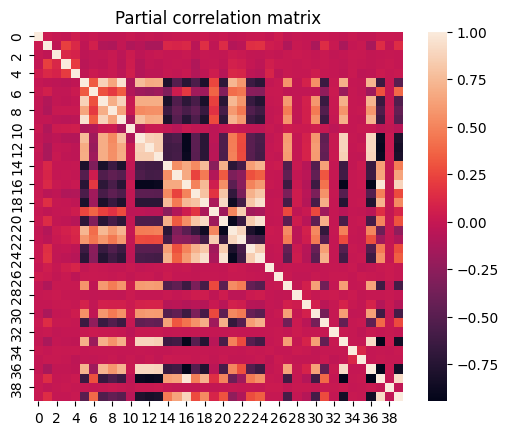

In [ ]:
overall_pearson_r = df_clean.corr()
sns.heatmap(overall_pearson_r.values[95:135,95:135], vmax=1., square=True)
plt.title('Partial correlation matrix')
plt.show()

In [ ]:
df_clean.columns[95:135]

Index(['GT_31799', 'TT_33701', 'PDT_33710', 'PT_24099', 'PT_34101', 'ST_31131',
       'GT_31130', 'PT_31130', 'PT_31150', 'ST_31151', 'PT_31355', 'ST_31331',
       'PT_31330', 'PT_31202', 'GT_31330', 'TT_31330', 'TT_31355', 'ST_31531',
       'GT_31530', 'TT_31530', 'PT_31530', 'TT_31555', 'TT_31550', 'PT_31550',
       'ST_31551', 'PT_31555', 'GT_31730', 'PT_31730', 'ST_31731', 'TT_31730',
       'PT_31755', 'TT_31755', 'GT_31750', 'PT_31650', 'GT_31650', 'GT_31620',
       'PT_31641', 'TT_31640', 'GT_31630', 'TT_31650'],
      dtype='object')

## **Partial Mutual information matrix**

## **Causal discovery**

https://github.com/jakobrunge/tigramite/blob/master/tutorials/causal_discovery/tigramite_tutorial_pcmciplus.ipynb

In [ ]:
import tigramite
from tigramite.models import LinearMediation, Models
from tigramite.causal_effects import CausalEffects

In [ ]:
df_sub0=df_clean.iloc[:,0:25]
df_sub1=df_clean.iloc[:,0:55]
df_sub2=df_clean.iloc[:,55:95]
df_sub3=df_clean.iloc[:,95:135]

In [ ]:
var_names=df_clean.columns
var_names0=df_sub0.columns
var_names1=df_sub1.columns
var_names2=df_sub2.columns
var_names3=df_sub3.columns

In [ ]:
dataframe_tot = pp.DataFrame(df_clean.values, var_names=df_clean.columns)
dataframe0 = pp.DataFrame(df_sub0.values, var_names=df_sub0.columns)
dataframe1 = pp.DataFrame(df_sub1.values, var_names=df_sub1.columns)
dataframe2 = pp.DataFrame(df_sub2.values, var_names=df_sub2.columns)
dataframe3 = pp.DataFrame(df_sub3.values, var_names=df_sub3.columns)

/usr/local/lib/python3.11/dist-packages/tigramite/plotting.py:391: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  pyplot.tight_layout()


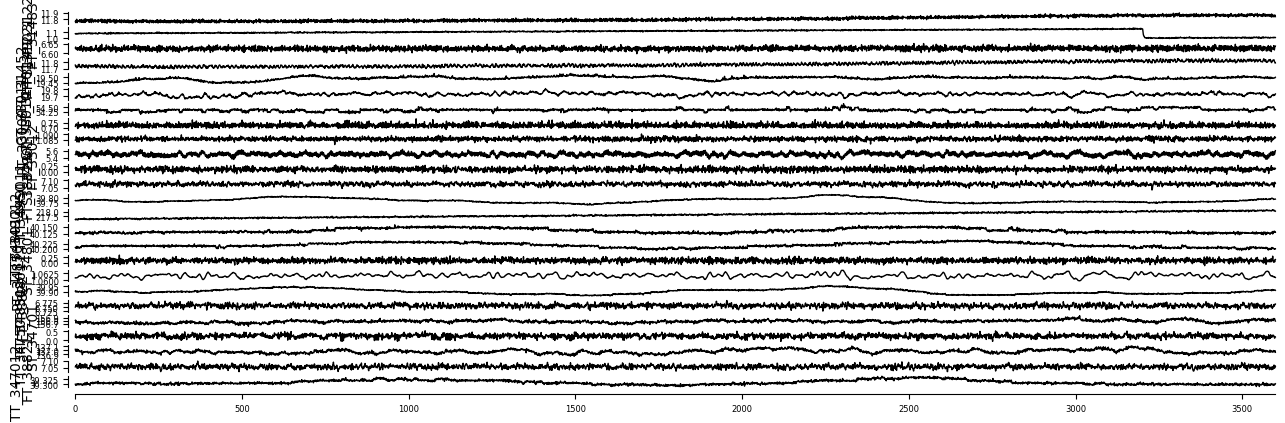

In [ ]:
tp.plot_timeseries(dataframe0, figsize=(15, 5)); plt.show()

In [ ]:
dataframeTT = pp.DataFrame(dfTT.values, var_names=dfTT.columns)
dataframePT = pp.DataFrame(dfPT.values, var_names=dfPT.columns)
dataframeST = pp.DataFrame(dfST.values, var_names=dfST.columns)

/usr/local/lib/python3.11/dist-packages/tigramite/plotting.py:391: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  pyplot.tight_layout()


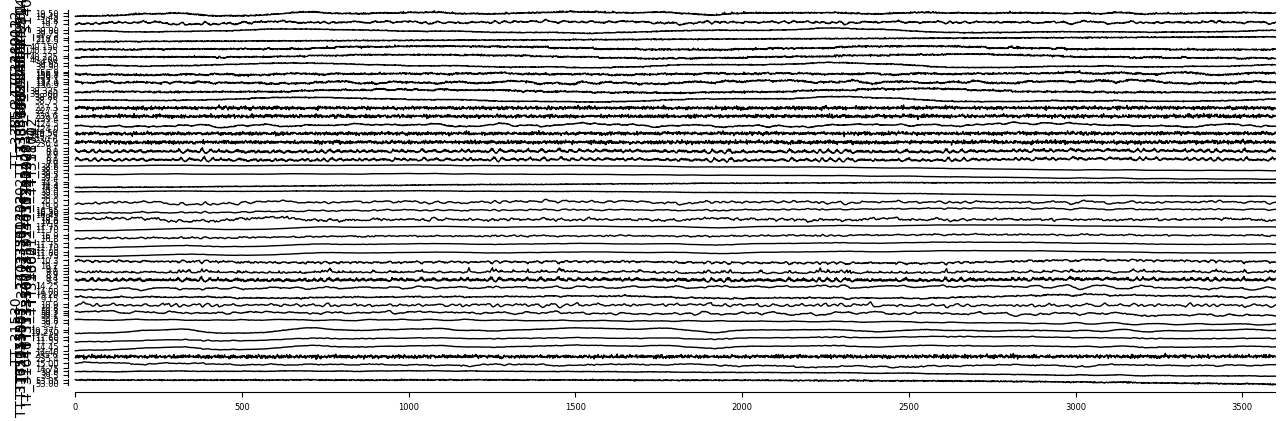

In [ ]:
tp.plot_timeseries(dataframeTT, figsize=(15, 5)); plt.show()

/usr/local/lib/python3.11/dist-packages/tigramite/plotting.py:391: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  pyplot.tight_layout()


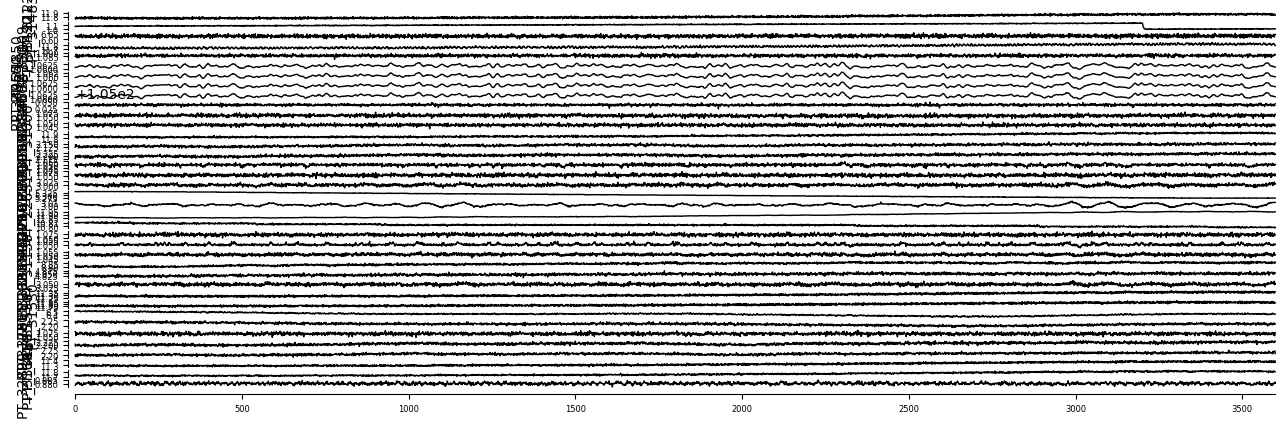

In [ ]:
tp.plot_timeseries(dataframePT, figsize=(15, 5)); plt.show()

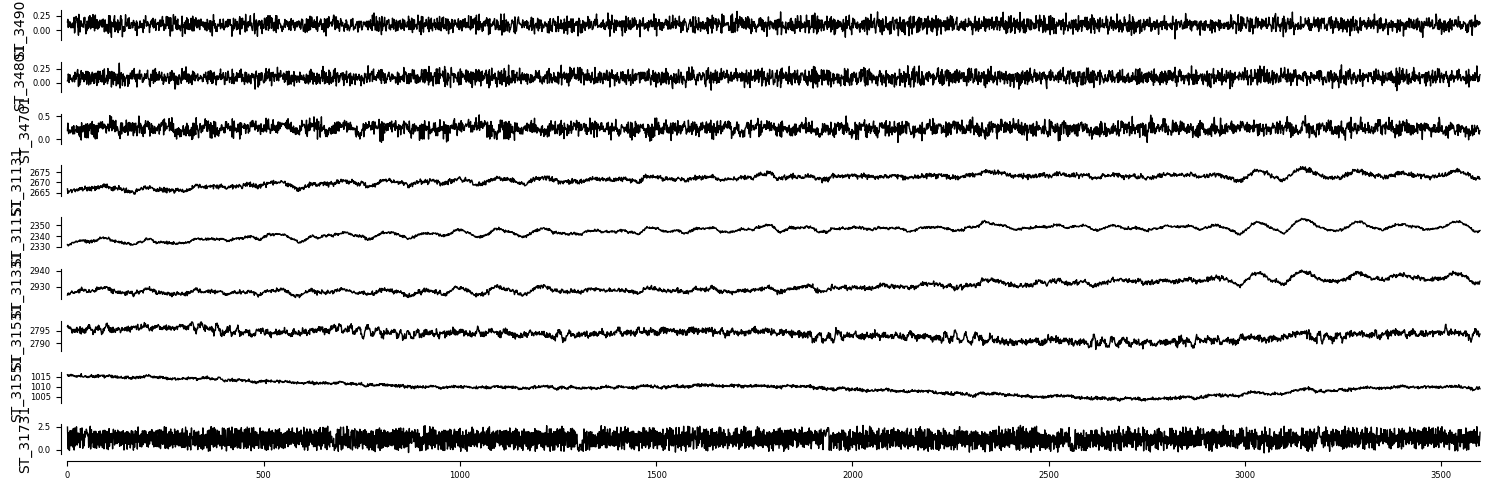

In [ ]:
tp.plot_timeseries(dataframeST, figsize=(15, 5)); plt.show()

In [ ]:
from tigramite.independence_tests.parcorr import ParCorr
from tigramite.independence_tests.cmiknn import CMIknn
from tigramite.independence_tests.cmisymb import CMIsymb

In [ ]:
parcorr = ParCorr(significance='analytic')
pcmci_tot = PCMCI(
    dataframe=dataframe_tot,
    cond_ind_test=parcorr,
    verbosity=1)

In [ ]:
parcorr = ParCorr(significance='analytic')
pcmci0 = PCMCI(
    dataframe=dataframe0,
    cond_ind_test=parcorr,
    verbosity=1)

In [ ]:
parcorr = ParCorr(significance='analytic')
pcmci1 = PCMCI(
    dataframe=dataframe1,
    cond_ind_test=parcorr,
    verbosity=1)

In [ ]:
parcorr = ParCorr(significance='analytic')
pcmci2 = PCMCI(
    dataframe=dataframe2,
    cond_ind_test=parcorr,
    verbosity=1)

In [ ]:
parcorr = ParCorr(significance='analytic')
pcmci3 = PCMCI(
    dataframe=dataframe3,
    cond_ind_test=parcorr,
    verbosity=1)

In [ ]:
var_namesST=dfST.columns

In [ ]:
parcorr = ParCorr(significance='analytic')
pcmciST = PCMCI(
    dataframe=dataframeST,
    cond_ind_test=parcorr,
    verbosity=1)

In [ ]:
parcorr = ParCorr(significance='analytic')
pcmciTT = PCMCI(
    dataframe=dataframeTT,
    cond_ind_test=parcorr,
    verbosity=1)

Correlation with time


##
## Running Tigramite BivCI algorithm
##

Parameters:

independence test = par_corr
tau_min = 0
tau_max = 10


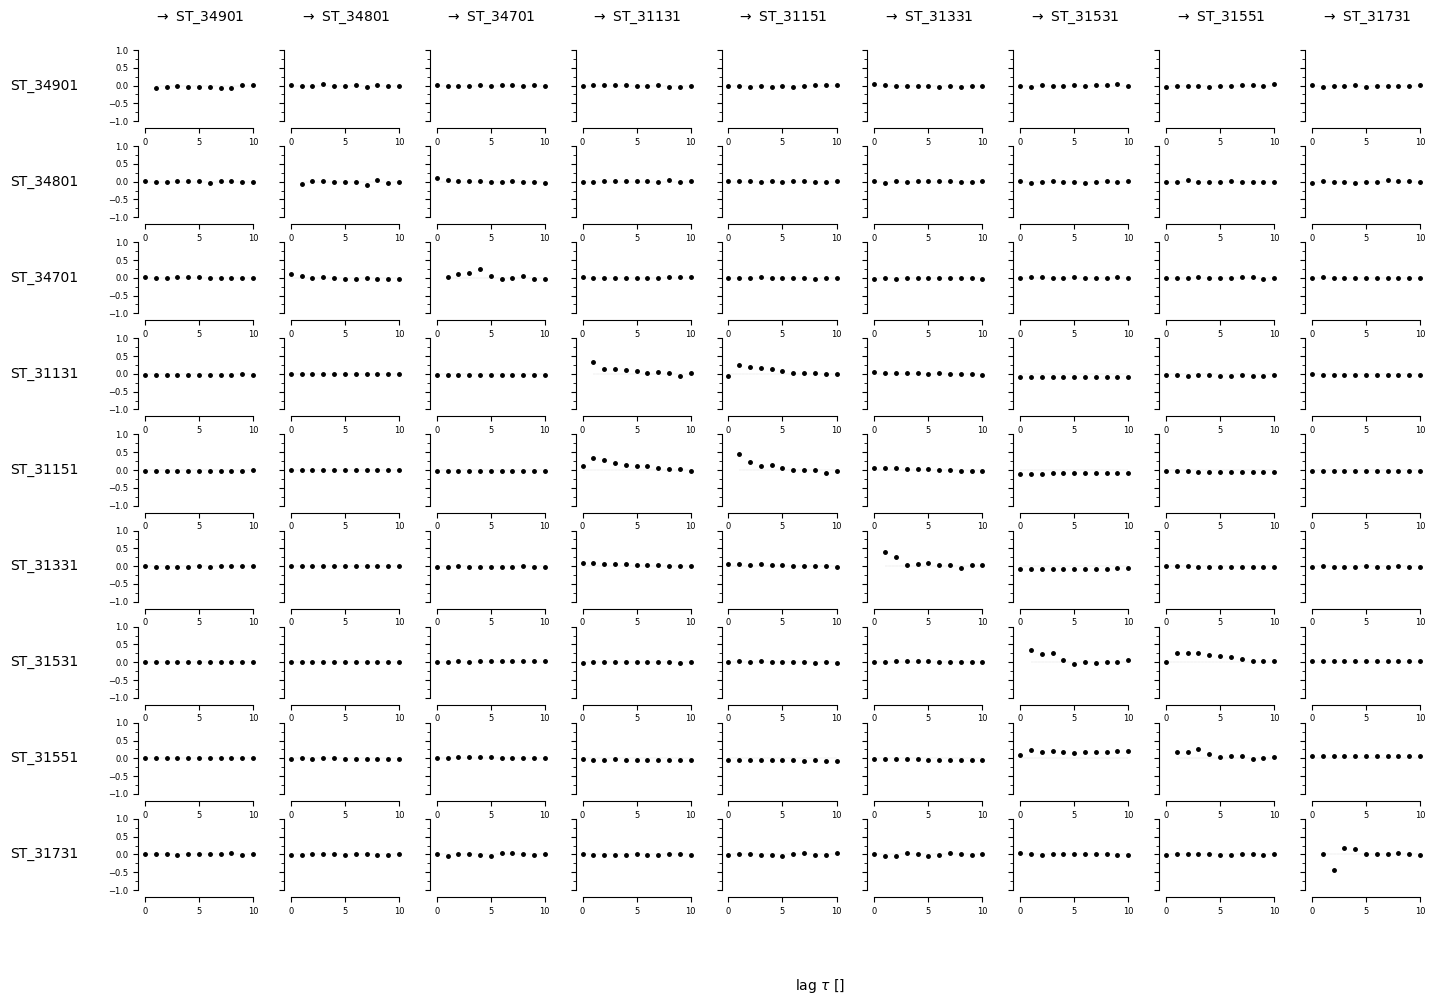

In [ ]:
correlations = pcmciST.run_bivci(tau_max=10, val_only=True)['val_matrix']
lag_func_matrix = tp.plot_lagfuncs(val_matrix=correlations,
                                   setup_args={'var_names':var_namesST, 'figsize':(15, 10),
                                    'x_base':5, 'y_base':.5})

In [ ]:
tau_max = 10
pc_alpha = 0.01
pcmciST.verbosity = 2

results = pcmciST.run_pcmciplus(tau_min=0, tau_max=tau_max, pc_alpha=pc_alpha)

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
    Subset 0: (ST_31531 -1) (ST_31531 -3)  gives pval = 0.00000 / val =  0.209
    Still subsets of dimension 2 left, but q_max = 1 reached.

    Link (ST_31551 -6) -?> ST_31531 (9/50):
    Subset 0: (ST_31531 -1) (ST_31531 -3)  gives pval = 0.00000 / val =  0.215
    Still subsets of dimension 2 left, but q_max = 1 reached.

    Link (ST_31551 -7) -?> ST_31531 (10/50):
    Subset 0: (ST_31531 -1) (ST_31531 -3)  gives pval = 0.00000 / val =  0.219
    Still subsets of dimension 2 left, but q_max = 1 reached.

    Link (ST_31551 -4) -?> ST_31531 (11/50):
    Subset 0: (ST_31531 -1) (ST_31531 -3)  gives pval = 0.00000 / val =  0.206
    Still subsets of dimension 2 left, but q_max = 1 reached.

    Link (ST_31551 -5) -?> ST_31531 (12/50):
    Subset 0: (ST_31531 -1) (ST_31531 -3)  gives pval = 0.00000 / val =  0.208
    Still subsets of dimension 2 left, but q_max = 1 reached.

    Link (ST_31551 -8) -?> ST_315

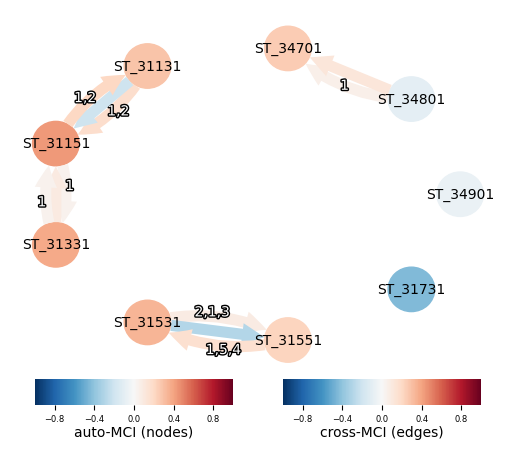

In [ ]:
tp.plot_graph(
    val_matrix=results['val_matrix'],
    graph=results['graph'],
    var_names=var_namesST,
    link_colorbar_label='cross-MCI (edges)',
    node_colorbar_label='auto-MCI (nodes)',
    ); plt.show()

 ['C1', ['ST_34901', 'FT_38823', 'TT_349011', 'TT_34950', 'TT_349012']],
 ['C2',['TT_348012', 'ST_34801', 'PT_34850', 'TT_348011', 'FT_38822', 'TT_34850']],
 ['C3',['ST_34701', 'TT_34750', 'FT_38821', 'TT_347012', 'PT_34750', 'TT_347011']],

['T1', ['ST_31131', 'GT_31130', 'PT_31130']],
 ['T2', ['PT_31150', 'ST_31151']],
 ['T3',['PT_31355','ST_31331','PT_31330','PT_31202','GT_31330','TT_31330','TT_31355']],
 ['T4', ['ST_31531', 'GT_31530', 'TT_31530', 'PT_31530']],
 ['T5', ['TT_31555', 'TT_31550', 'PT_31550', 'ST_31551', 'PT_31555']],
 ['T6',['GT_31730','PT_31730','ST_31731','TT_31730','PT_31755','TT_31755','GT_31750']],

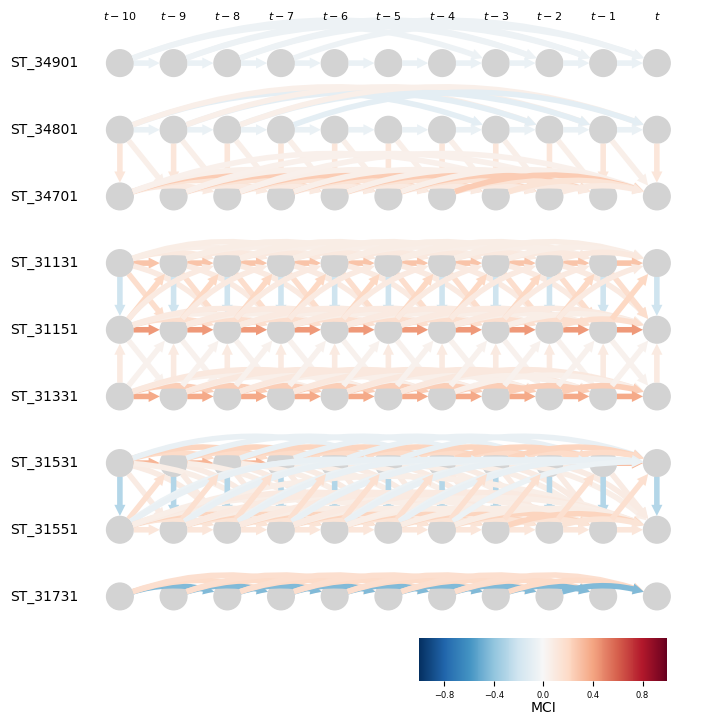

In [ ]:
# Plot time series graph
tp.plot_time_series_graph(
    figsize=(8, 8),
    node_size=0.05,
    val_matrix=results['val_matrix'],
    graph=results['graph'],
    var_names=var_namesST,
    link_colorbar_label='MCI',
    ); plt.show()

In [ ]:
correlations = pcmciTT.run_bivci(tau_max=10, val_only=True)['val_matrix']
lag_func_matrix = tp.plot_lagfuncs(val_matrix=correlations,
                                   setup_args={'var_names':dfTT.columns, 'figsize':(15, 10),
                                    'x_base':5, 'y_base':.5})


##
## Running Tigramite BivCI algorithm
##

Parameters:

independence test = par_corr
tau_min = 0
tau_max = 10
